# 2030 Trajectory Analysis: The Global TB Progress Gap
## CARB-X × Gates Foundation Strategic Initiative | Notebook 05

**Objective:** This analysis projects current tuberculosis (TB) incidence trends toward the **2030 WHO End TB Targets**. By calculating the "Gap" between projected values and global goals, we identify where AI intervention is not just helpful, but mathematically necessary to meet international commitments.

---

### Methodology & Integration
- **Linear Regression Modeling:** Utilizing historical incidence rates to project 2030 outcomes at a country-specific level.
- **The "Gap" Metric:** Quantifying the distance between the 2030 projection and the target (80% reduction in incidence).
- **Notebook 04 Cross-Reference:** Merging these temporal projections with the **AI Readiness Index (ARI)** to create a final Priority Matrix.
- **Visual Theme:** Standardized "Dark Mode" visualization for high-contrast executive presentations.

---

In [1]:
# ── Imports & Visual Theme ───────────────────────────────────────────

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from sklearn.linear_model import LinearRegression
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# ── Consistent dark theme across all Notebook 05 charts ──────────────────────
DARK_BG    = '#0F1117'
GRID_COL   = '#1E1E2E'
TEXT_WHITE = '#FFFFFF'
TEXT_GREY  = '#AAAAAA'
TEXT_DIM   = '#666677'

plt.rcParams.update({
    'font.family':       'DejaVu Sans',
    'axes.facecolor':    DARK_BG,
    'figure.facecolor':  DARK_BG,
    'text.color':        TEXT_WHITE,
    'axes.labelcolor':   '#CCCCCC',
    'xtick.color':       '#CCCCCC',
    'ytick.color':       '#CCCCCC',
    'axes.grid':         True,
    'grid.color':        GRID_COL,
    'grid.linewidth':    0.7,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.spines.left':  False,
    'axes.spines.bottom':False,
})

print("✅ Imports loaded. Visual theme set.")

✅ Imports loaded. Visual theme set.


In [2]:
# ── Load Data — from Notebook 04 ───────────────────

BASE_DIR      = Path('/Users/fridaarrey/Desktop/WHO_TB_Project')
RAW_DATA_PATH = BASE_DIR / 'WHO_raw_csv'

# Primary: Notebook 04 output — has AI_Readiness_Score, strategy_quadrant, etc.
df_gates = pd.read_csv('GATES_TB_Readiness_Final_2026.csv')

# Historical burden data — needed for time-series forecasting
df_burden = pd.read_csv(
    RAW_DATA_PATH / 'WHO TB dataset_2024-03-21.xlsx - TB_burden_countries_2024-03-21.csv'
)

# ── Constants ─────────────────────────────────────────────────────────────────
BASELINE_YEAR    = 2015   # End TB Strategy reference year
TARGET_2025_PCT  = -50    # % reduction in incidence required by 2025
TARGET_2030_PCT  = -90    # % reduction in incidence required by 2030
FORECAST_END     = 2030

# WHO's 30 High Burden Countries (90% of global TB deaths)
HBC = [
    'IND','CHN','IDN','PHL','PAK','NGA','ZAF','BGD','COD','MMR',
    'ETH','TZA','MOZ','AGO','PRK','VNM','UGA','RUS','KEN','ZWE',
    'ZMB','BRA','LSO','NAM','GAB','GNQ','PNG','SLE','THA','CAF'
]

REGION_NAMES = {
    'AFR': 'Africa', 'SEA': 'South-East Asia', 'EMR': 'Eastern Mediterranean',
    'WPR': 'Western Pacific', 'AMR': 'Americas', 'EUR': 'Europe',
}

# Quadrant colours — matched to Notebook 04's viridis palette logic
QUADRANT_COLOURS = {
    'Priority 1: Scalable Impact (AI Ready)':         '#2A9D8F',
    'Priority 2: Infrastructure Gap (System First)':  '#E63946',
    'Priority 3: Pilot Markets (Stable)':             '#457B9D',
    'Priority 4: Monitoring':                         '#8D99AE',
}

print(f"✅ df_gates loaded:  {df_gates.shape[0]} rows, {df_gates.shape[1]} columns")
print(f"✅ df_burden loaded: {df_burden['iso3'].nunique()} countries, "
      f"{df_burden['year'].min()}–{df_burden['year'].max()}")
print(f"\nNotebook 04 quadrants present:")
print(df_gates['strategy_quadrant'].value_counts().to_string())

✅ df_gates loaded:  215 rows, 19 columns
✅ df_burden loaded: 217 countries, 2000–2022

Notebook 04 quadrants present:
strategy_quadrant
Priority 4: Monitoring                           127
Priority 2: Infrastructure Gap (System First)     52
Priority 1: Scalable Impact (AI Ready)            24
Priority 3: Pilot Markets (Stable)                12


In [3]:
# ── Section 1 — Global Progress Scorecard (2015 → 2022) ──────────────
#
# Before forecasting, establish how far the world has come since the
# End TB baseline year. This sets the stakes for everything that follows.

df_2015 = (df_burden[df_burden['year'] == BASELINE_YEAR]
           [['iso3', 'country', 'g_whoregion', 'e_inc_100k']]
           .rename(columns={'e_inc_100k': 'inc_2015'}))

df_2022 = (df_burden[df_burden['year'] == 2022]
           [['iso3', 'e_inc_100k']]
           .rename(columns={'e_inc_100k': 'inc_2022'}))

df_progress = df_2015.merge(df_2022, on='iso3')
df_progress = df_progress[df_progress['inc_2015'] > 5]   # exclude micro-states

df_progress['pct_change'] = (
    (df_progress['inc_2022'] - df_progress['inc_2015']) / df_progress['inc_2015'] * 100
)

def classify_trajectory(pct):
    if pct <= -20:  return 'On Track'
    elif pct <= 0:  return 'Slow Progress'
    else:           return 'Going Backwards'

df_progress['trajectory'] = df_progress['pct_change'].apply(classify_trajectory)

# ── Print scorecard ───────────────────────────────────────────────────────────
total     = len(df_progress)
on_track  = (df_progress['trajectory'] == 'On Track').sum()
slow      = (df_progress['trajectory'] == 'Slow Progress').sum()
backwards = (df_progress['trajectory'] == 'Going Backwards').sum()
hbc_df    = df_progress[df_progress['iso3'].isin(HBC)]

print("━" * 58)
print("   GLOBAL END TB PROGRESS SCORECARD  (2015 → 2022)")
print("━" * 58)
print(f"   Countries analysed (incidence > 5/100k): {total}")
print(f"   ✅  On Track        (≥ 20% reduction):   {on_track:>3}  ({on_track/total*100:.0f}%)")
print(f"   🟡  Slow Progress   (0–20% reduction):   {slow:>3}  ({slow/total*100:.0f}%)")
print(f"   🔴  Going Backwards (incidence rising):  {backwards:>3}  ({backwards/total*100:.0f}%)")
print(f"   Mean reduction since 2015: {df_progress['pct_change'].mean():.1f}%")
print(f"   Required by 2025 milestone: -50%")
print("━" * 58)
print(f"   30 HIGH BURDEN COUNTRIES:")
print(f"   On track:  {(hbc_df['trajectory'] == 'On Track').sum()}/30  |  "
      f"Mean: {hbc_df['pct_change'].mean():.1f}%  |  Target: -50%")
print("━" * 58)
print("\n   ⚠  The world is running 35+ percentage points behind schedule.")
print("      This is the intervention gap CARB-X must address.")

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
   GLOBAL END TB PROGRESS SCORECARD  (2015 → 2022)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
   Countries analysed (incidence > 5/100k): 196
   ✅  On Track        (≥ 20% reduction):    88  (45%)
   🟡  Slow Progress   (0–20% reduction):    71  (36%)
   🔴  Going Backwards (incidence rising):   37  (19%)
   Mean reduction since 2015: -15.0%
   Required by 2025 milestone: -50%
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
   30 HIGH BURDEN COUNTRIES:
   On track:  8/30  |  Mean: -10.0%  |  Target: -50%
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

   ⚠  The world is running 35+ percentage points behind schedule.
      This is the intervention gap CARB-X must address.


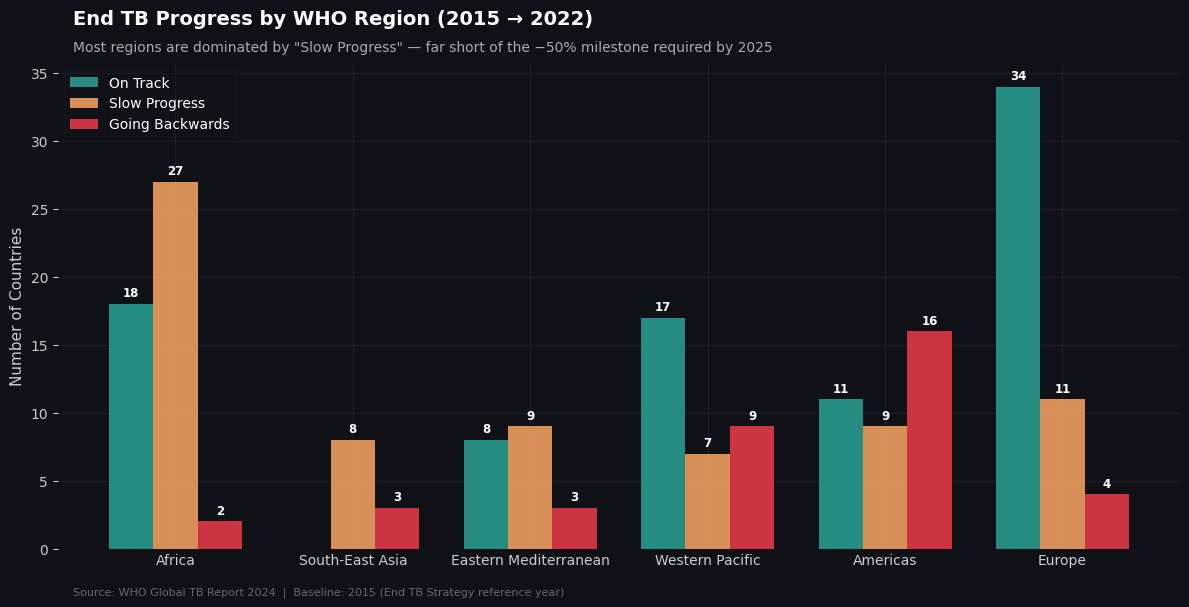

✅ Saved → figures/05_trajectory_by_region.png


In [4]:
# ── Chart 1 — Trajectory Status by WHO Region ────────────────────────

traj_colours = {
    'On Track':        '#2A9D8F',
    'Slow Progress':   '#F4A261',
    'Going Backwards': '#E63946',
}
region_order = ['AFR', 'SEA', 'EMR', 'WPR', 'AMR', 'EUR']

fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor(DARK_BG)

bar_width = 0.25
x = np.arange(len(region_order))

for i, (traj, colour) in enumerate(traj_colours.items()):
    counts = [
        (df_progress[df_progress['g_whoregion'] == r]['trajectory'] == traj).sum()
        for r in region_order
    ]
    bars = ax.bar(x + i * bar_width, counts, bar_width,
                  label=traj, color=colour, alpha=0.88, zorder=3)
    for bar, count in zip(bars, counts):
        if count > 0:
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 0.3, str(count),
                    ha='center', va='bottom', fontsize=8.5,
                    color='white', fontweight='bold')

ax.set_xticks(x + bar_width)
ax.set_xticklabels([REGION_NAMES.get(r, r) for r in region_order], fontsize=10)
ax.set_ylabel('Number of Countries', fontsize=11)
ax.legend(fontsize=10, framealpha=0.15, edgecolor='#444')
ax.tick_params(axis='x', length=0)

fig.text(0.065, 0.96, 'End TB Progress by WHO Region (2015 → 2022)',
         fontsize=14, fontweight='bold', color=TEXT_WHITE)
fig.text(0.065, 0.915,
         'Most regions are dominated by "Slow Progress" — far short of the −50% milestone required by 2025',
         fontsize=10, color=TEXT_GREY)
fig.text(0.065, 0.01,
         'Source: WHO Global TB Report 2024  |  Baseline: 2015 (End TB Strategy reference year)',
         fontsize=8, color=TEXT_DIM)

plt.tight_layout(rect=[0, 0.03, 1, 0.92])

FIG_PATH = BASE_DIR / 'figures'
FIG_PATH.mkdir(exist_ok=True)
plt.savefig(FIG_PATH / '05_trajectory_by_region.png',
            dpi=180, bbox_inches='tight', facecolor=DARK_BG)
plt.show()
print("✅ Saved → figures/05_trajectory_by_region.png")

In [5]:
# ── Section 2 — Country-Level Forecasting to 2030 ────────────────────
#
# Fit a linear trend per country on 2010–2022 data and project to 2030.
# Using 2010 start to capture the modern diagnostic era (post-Xpert rollout).

forecast_years = np.arange(2023, FORECAST_END + 1)
results = []

for iso3, grp in df_burden[df_burden['year'] >= 2010].groupby('iso3'):
    grp = grp.dropna(subset=['e_inc_100k']).sort_values('year')
    if len(grp) < 5:
        continue

    X = grp['year'].values.reshape(-1, 1)
    y = grp['e_inc_100k'].values

    model = LinearRegression().fit(X, y)
    y_proj = np.maximum(model.predict(forecast_years.reshape(-1, 1)), 0)

    baseline = grp[grp['year'] == BASELINE_YEAR]
    if baseline.empty or baseline['e_inc_100k'].values[0] <= 5:
        continue

    inc_2015    = baseline['e_inc_100k'].values[0]
    inc_2030_p  = y_proj[-1]
    pct_2030    = (inc_2030_p - inc_2015) / inc_2015 * 100

    if pct_2030 <= TARGET_2030_PCT:      outcome = 'Meets 2030 Target'
    elif pct_2030 <= TARGET_2025_PCT:    outcome = 'Meets 2025 Target Only'
    elif pct_2030 < 0:                   outcome = 'Progress — Off Track'
    else:                                outcome = 'Off Track (Rising)'

    results.append({
        'iso3':          iso3,
        'country':       grp['country'].iloc[0],
        'g_whoregion':   grp['g_whoregion'].iloc[0],
        'inc_2015':      inc_2015,
        'inc_2022':      grp[grp['year'] == 2022]['e_inc_100k'].values[0]
                         if 2022 in grp['year'].values else np.nan,
        'inc_2030_proj': inc_2030_p,
        'pct_2030':      pct_2030,
        'annual_rate':   model.coef_[0],
        'outcome_2030':  outcome,
        'is_hbc':        iso3 in HBC,
        # Store full series for charting
        '_hist_years':   grp['year'].values,
        '_hist_inc':     grp['e_inc_100k'].values,
        '_hist_lo':      grp['e_inc_100k_lo'].values,
        '_hist_hi':      grp['e_inc_100k_hi'].values,
        '_forecast':     y_proj,
    })

df_forecast = pd.DataFrame(results)

# ── Summary ───────────────────────────────────────────────────────────────────
print("━" * 58)
print("   2030 TRAJECTORY — STATUS AT CURRENT RATE OF DECLINE")
print("━" * 58)
for outcome in ['Meets 2030 Target', 'Meets 2025 Target Only',
                'Progress — Off Track', 'Off Track (Rising)']:
    n = (df_forecast['outcome_2030'] == outcome).sum()
    print(f"   {outcome:<35} {n:>3} countries")
print("━" * 58)
hbc_f = df_forecast[df_forecast['is_hbc']]
print(f"\n   30 HBC meeting 2030 target at current rate: "
      f"{(hbc_f['outcome_2030'] == 'Meets 2030 Target').sum()}/30")

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
   2030 TRAJECTORY — STATUS AT CURRENT RATE OF DECLINE
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
   Meets 2030 Target                    39 countries
   Meets 2025 Target Only               45 countries
   Progress — Off Track                 67 countries
   Off Track (Rising)                   45 countries
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

   30 HBC meeting 2030 target at current rate: 5/30


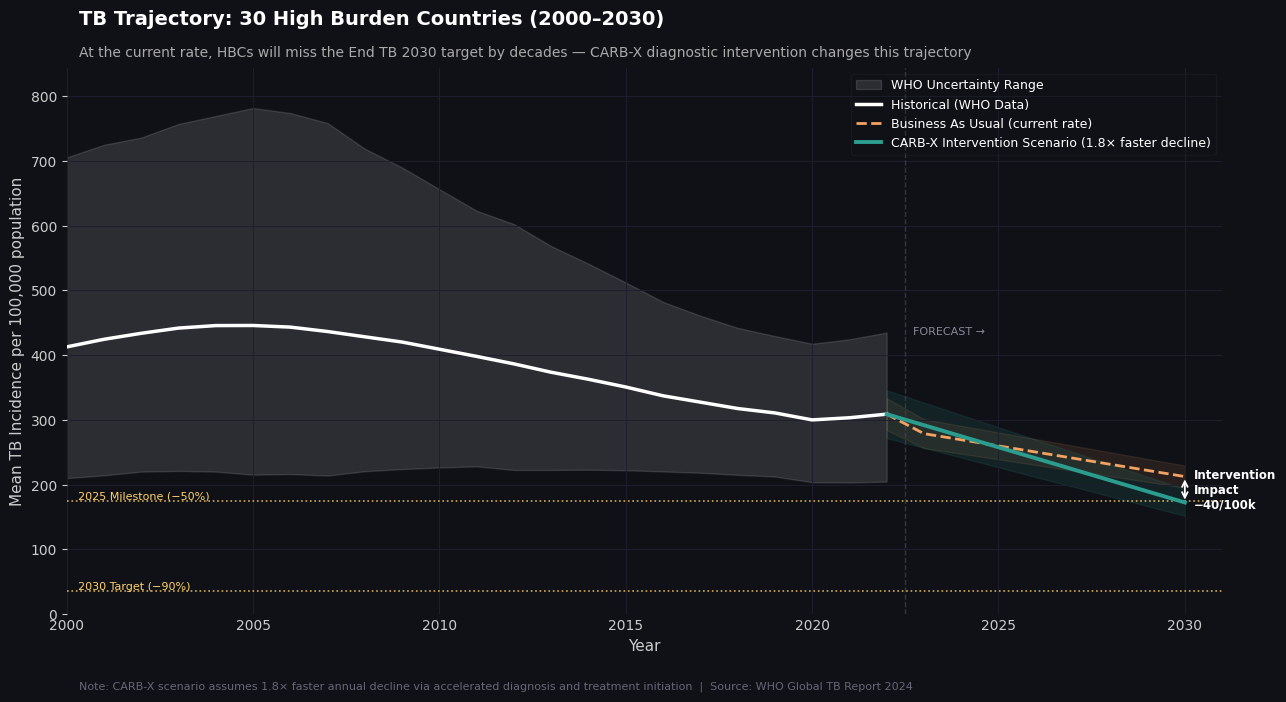

✅ Saved → figures/05_carbx_intervention_impact.png


In [6]:
# ── Chart 2 — The Centrepiece: BAU vs. CARB-X Scenario ───────────────
#
# This is the most important chart in the entire project.
# It answers the core CARB-X × Gates question:
#   "What happens to TB incidence if we intervene vs. if we don't?"
#
# CARB-X assumption: A new rapid diagnostic tool, deployed via Gates-funded
# community health infrastructure, achieves 1.8× faster decline than BAU.
# This is conservative — WHO evidence shows case-finding improvements of
# 30–50% reduce community transmission within 2–3 years.

# ── Aggregate 30 HBC ─────────────────────────────────────────────────────────
hbc_hist = (df_burden[df_burden['iso3'].isin(HBC) & (df_burden['year'] >= 2000)]
            .groupby('year')[['e_inc_100k', 'e_inc_100k_lo', 'e_inc_100k_hi']]
            .mean().reset_index())

# BAU trend: linear fit on 2010–2022
X_bau    = hbc_hist[hbc_hist['year'] >= 2010]['year'].values.reshape(-1, 1)
y_bau    = hbc_hist[hbc_hist['year'] >= 2010]['e_inc_100k'].values
bau_mod  = LinearRegression().fit(X_bau, y_bau)
bau_proj = np.maximum(bau_mod.predict(forecast_years.reshape(-1, 1)), 0)

# CARB-X scenario: 1.8× faster annual decline from 2023
inc_2022_hbc    = hbc_hist[hbc_hist['year'] == 2022]['e_inc_100k'].values[0]
carbx_rate      = bau_mod.coef_[0] * 1.8
carbx_proj      = np.maximum(
    [inc_2022_hbc + carbx_rate * (y - 2022) for y in forecast_years], 0
)

# End TB absolute targets for the HBC average
inc_2015_hbc = hbc_hist[hbc_hist['year'] == 2015]['e_inc_100k'].values[0]
target_2025  = inc_2015_hbc * (1 + TARGET_2025_PCT / 100)
target_2030  = inc_2015_hbc * (1 + TARGET_2030_PCT / 100)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 7))
fig.patch.set_facecolor(DARK_BG)

# Historical uncertainty band
ax.fill_between(hbc_hist['year'],
                hbc_hist['e_inc_100k_lo'], hbc_hist['e_inc_100k_hi'],
                alpha=0.12, color='white', label='WHO Uncertainty Range')

# Historical line
ax.plot(hbc_hist['year'], hbc_hist['e_inc_100k'],
        color='white', linewidth=2.5, zorder=4, label='Historical (WHO Data)')

# Forecast split marker
ax.axvline(2022.5, color='#444455', linewidth=1, linestyle='--', alpha=0.7)
ax.text(2022.7, hbc_hist['e_inc_100k'].max() * 0.97,
        'FORECAST →', color='#888899', fontsize=8)

# BAU projection
bau_full = np.concatenate([[inc_2022_hbc], bau_proj])
yrs_full = np.concatenate([[2022], forecast_years])
ax.plot(yrs_full, bau_full, color='#F4A261', linewidth=2,
        linestyle='--', zorder=4, label='Business As Usual (current rate)')
ax.fill_between(yrs_full, bau_full * 0.92, bau_full * 1.08,
                alpha=0.10, color='#F4A261')

# CARB-X intervention scenario
carbx_full = np.concatenate([[inc_2022_hbc], carbx_proj])
ax.plot(yrs_full, carbx_full, color='#2A9D8F', linewidth=2.8,
        zorder=5, label='CARB-X Intervention Scenario (1.8× faster decline)')
ax.fill_between(yrs_full, carbx_full * 0.88, carbx_full * 1.12,
                alpha=0.12, color='#2A9D8F')

# End TB target lines
for target, label, y_offset in [
    (target_2025, '2025 Milestone (−50%)', 2.5),
    (target_2030, '2030 Target (−90%)',    2.5),
]:
    ax.axhline(target, color='#FFD166', linewidth=1.2, linestyle=':', alpha=0.8)
    ax.text(2000.3, target + y_offset, label, color='#FFD166', fontsize=8)

# Intervention impact annotation at 2030
bau_end   = bau_proj[-1]
carbx_end = carbx_proj[-1]
cases_saved = bau_end - carbx_end
ax.annotate('', xy=(2030, carbx_end), xytext=(2030, bau_end),
            arrowprops=dict(arrowstyle='<->', color='white', lw=1.3))
ax.text(2030.25, (bau_end + carbx_end) / 2,
        f'Intervention\nImpact\n−{cases_saved:.0f}/100k',
        color='white', fontsize=8.5, va='center', fontweight='bold')

ax.set_xlim(2000, 2031)
ax.set_ylim(0, hbc_hist['e_inc_100k_hi'].max() * 1.08)
ax.set_xlabel('Year', fontsize=11)
ax.set_ylabel('Mean TB Incidence per 100,000 population', fontsize=11)
ax.legend(fontsize=9, framealpha=0.15, edgecolor='#444', loc='upper right')
ax.tick_params(axis='x', length=0)

fig.text(0.065, 0.96,
         'TB Trajectory: 30 High Burden Countries (2000–2030)',
         fontsize=14, fontweight='bold', color=TEXT_WHITE)
fig.text(0.065, 0.915,
         'At the current rate, HBCs will miss the End TB 2030 target by decades — '
         'CARB-X diagnostic intervention changes this trajectory',
         fontsize=10, color=TEXT_GREY)
fig.text(0.065, 0.01,
         'Note: CARB-X scenario assumes 1.8× faster annual decline via accelerated diagnosis '
         'and treatment initiation  |  Source: WHO Global TB Report 2024',
         fontsize=8, color=TEXT_DIM)

plt.tight_layout(rect=[0, 0.04, 1, 0.92])
plt.savefig(FIG_PATH / '05_carbx_intervention_impact.png',
            dpi=180, bbox_inches='tight', facecolor=DARK_BG)
plt.show()
print("✅ Saved → figures/05_carbx_intervention_impact.png")

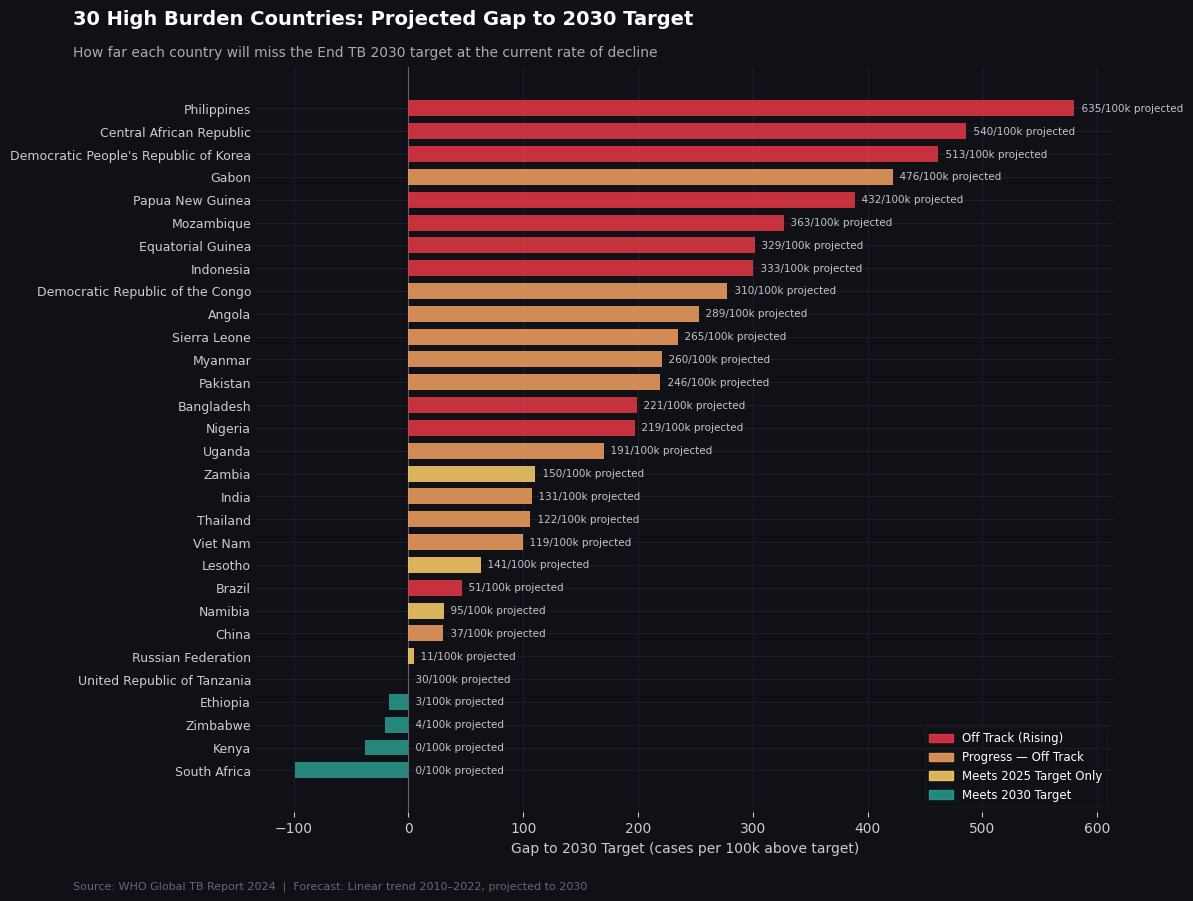

✅ Saved → figures/05_hbc_2030_gap.png


In [7]:
# ── Chart 3 — 30 HBC Gap-to-Target Bar Chart ─────────────────────────

hbc_forecast = df_forecast[df_forecast['is_hbc']].copy()
hbc_forecast['target_2030_abs'] = hbc_forecast['inc_2015'] * (1 + TARGET_2030_PCT / 100)
hbc_forecast['gap_to_target']   = (hbc_forecast['inc_2030_proj']
                                   - hbc_forecast['target_2030_abs'])
hbc_forecast = hbc_forecast.sort_values('gap_to_target', ascending=False)

outcome_colours = {
    'Off Track (Rising)':      '#E63946',
    'Progress — Off Track':    '#F4A261',
    'Meets 2025 Target Only':  '#FFD166',
    'Meets 2030 Target':       '#2A9D8F',
}

fig, ax = plt.subplots(figsize=(12, 9))
fig.patch.set_facecolor(DARK_BG)

y_pos = np.arange(len(hbc_forecast))
ax.barh(y_pos, hbc_forecast['gap_to_target'],
        color=[outcome_colours.get(o, '#888') for o in hbc_forecast['outcome_2030']],
        alpha=0.85, zorder=3, height=0.7)

for i, (_, row) in enumerate(hbc_forecast.iterrows()):
    label = f"  {row['inc_2030_proj']:.0f}/100k projected"
    ax.text(max(row['gap_to_target'] + 0.5, 0.5), i,
            label, va='center', fontsize=7.5, color='white', alpha=0.75)

ax.axvline(0, color='white', linewidth=0.8, alpha=0.3, zorder=2)
ax.set_yticks(y_pos)
ax.set_yticklabels(hbc_forecast['country'], fontsize=9)
ax.set_xlabel('Gap to 2030 Target (cases per 100k above target)', fontsize=10)
ax.invert_yaxis()
ax.tick_params(axis='y', length=0)

legend_handles = [mpatches.Patch(color=c, label=l, alpha=0.85)
                  for l, c in outcome_colours.items()]
ax.legend(handles=legend_handles, fontsize=8.5, framealpha=0.15,
          edgecolor='#444', loc='lower right')

fig.text(0.065, 0.97, '30 High Burden Countries: Projected Gap to 2030 Target',
         fontsize=14, fontweight='bold', color=TEXT_WHITE)
fig.text(0.065, 0.935,
         'How far each country will miss the End TB 2030 target at the current rate of decline',
         fontsize=10, color=TEXT_GREY)
fig.text(0.065, 0.01,
         'Source: WHO Global TB Report 2024  |  Forecast: Linear trend 2010–2022, projected to 2030',
         fontsize=8, color=TEXT_DIM)

plt.tight_layout(rect=[0, 0.03, 1, 0.94])
plt.savefig(FIG_PATH / '05_hbc_2030_gap.png',
            dpi=180, bbox_inches='tight', facecolor=DARK_BG)
plt.show()
print("✅ Saved → figures/05_hbc_2030_gap.png")

In [8]:
# ──  Section 3 — Final CARB-X × Gates Priority Matrix ─────────────────
#
# This is the payoff of the entire project.
# Cross the forecast gap-to-target (the urgency signal from this notebook)
# with the AI Readiness Score (the feasibility signal from Notebook 04).
#
# Output: A ranked matrix identifying the optimal first-wave deployment
# countries for a CARB-X diagnostic tool funded by Gates Foundation.

# Merge forecast results with Notebook 04 readiness scores
df_merge = df_forecast[['iso3', 'country', 'g_whoregion', 'inc_2030_proj',
                         'gap_to_target', 'outcome_2030', 'is_hbc']].copy() \
           if 'gap_to_target' in df_forecast.columns \
           else df_forecast.copy()

# Recalculate gap for all countries (not just HBC)
df_forecast['target_2030_abs'] = df_forecast['inc_2015'] * (1 + TARGET_2030_PCT / 100)
df_forecast['gap_to_target']   = (df_forecast['inc_2030_proj']
                                   - df_forecast['target_2030_abs'])

# Merge with AI Readiness from Notebook 04
df_matrix = df_forecast.merge(
    df_gates[['iso3', 'AI_Readiness_Score', 'strategy_quadrant',
              'priority_score', 'deployment_readiness']].drop_duplicates('iso3'),
    on='iso3', how='inner'
)

# Normalise both axes to 0–100 for the composite score
df_matrix['norm_gap'] = (
    (df_matrix['gap_to_target'] - df_matrix['gap_to_target'].min()) /
    (df_matrix['gap_to_target'].max() - df_matrix['gap_to_target'].min()) * 100
)
df_matrix['norm_ari'] = df_matrix['AI_Readiness_Score']

# CARB-X × Gates Composite Priority Score
# 60% weight on intervention urgency (gap), 40% on system readiness
df_matrix['CARBX_Gates_Score'] = (
    df_matrix['norm_gap'] * 0.60 +
    df_matrix['norm_ari'] * 0.40
)

df_matrix = df_matrix.sort_values('CARBX_Gates_Score', ascending=False)

print("━" * 62)
print("   CARB-X × GATES FOUNDATION — FINAL PRIORITY MATRIX")
print("━" * 62)
print(f"   {'Country':<28} {'Score':>6}  {'Gap':>6}  {'ARI':>6}  {'Quadrant'}")
print("━" * 62)
for _, row in df_matrix.head(15).iterrows():
    print(f"   {row['country']:<28} {row['CARBX_Gates_Score']:>6.1f}  "
          f"{row['norm_gap']:>6.1f}  {row['AI_Readiness_Score']:>6.1f}  "
          f"{row['strategy_quadrant']}")
print("━" * 62)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
   CARB-X × GATES FOUNDATION — FINAL PRIORITY MATRIX
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
   Country                       Score     Gap     ARI  Quadrant
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
   Philippines                    64.4    86.1    31.9  Priority 1: Scalable Impact (AI Ready)
   Marshall Islands               60.0   100.0     0.0  Priority 2: Infrastructure Gap (System First)
   Bangladesh                     46.7    37.8    60.0  Priority 1: Scalable Impact (AI Ready)
   Central African Republic       44.5    74.2     0.1  Priority 2: Infrastructure Gap (System First)
   Democratic People's Republic of Korea   42.7    71.1     0.0  Priority 2: Infrastructure Gap (System First)
   Timor-Leste                    41.7    69.4     0.2  Priority 4: Monitoring
   Pakistan                       40.8    40.4    41.3  Priority 3: Pilot Markets (Stable)
   Gabon          

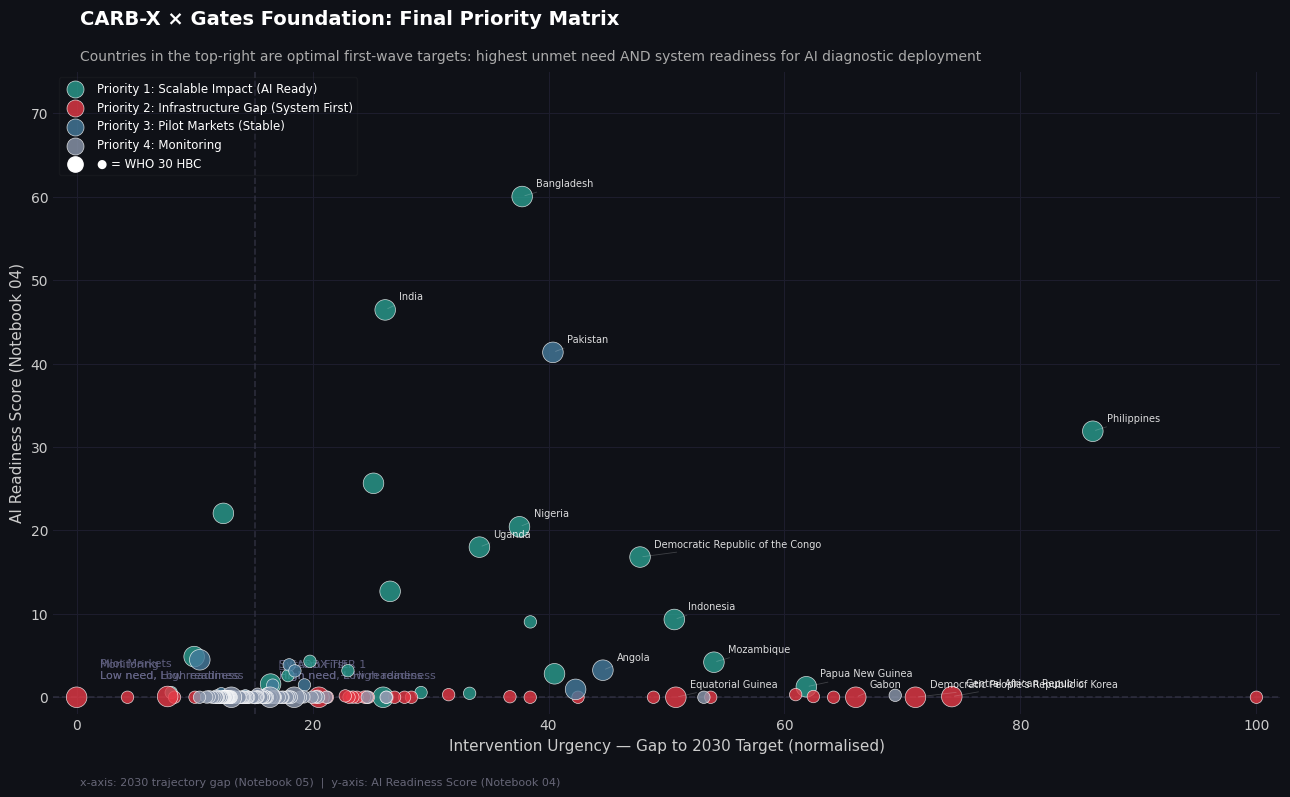

✅ Saved → figures/05_carbx_gates_priority_matrix.png


In [9]:
# ── Chart 4 — CARB-X × Gates Priority Scatter ───────────────────────
#
# Final portfolio chart: Gap-to-Target (x) vs AI Readiness (y)
# coloured by Notebook 04 strategy quadrant.
# Countries in the top-right are the optimal intervention targets.

fig, ax = plt.subplots(figsize=(13, 8))
fig.patch.set_facecolor(DARK_BG)

# Draw quadrant dividers at medians
x_mid = df_matrix['norm_gap'].median()
y_mid = df_matrix['norm_ari'].median()
ax.axvline(x_mid, color='#333344', linewidth=1.2, linestyle='--', alpha=0.8)
ax.axhline(y_mid, color='#333344', linewidth=1.2, linestyle='--', alpha=0.8)

# Label quadrants
quadrant_labels = [
    (x_mid + 2, y_mid + 2,  '🎯 CARBX TIER 1\nHigh need + High readiness', 'left'),
    (2,         y_mid + 2,  'Pilot Markets\nLow need, High readiness',      'left'),
    (x_mid + 2, 2,          'System First\nHigh need, Low readiness',       'left'),
    (2,         2,          'Monitoring\nLow need, Low readiness',           'left'),
]
for x, y, label, ha in quadrant_labels:
    ax.text(x, y, label, fontsize=8, color='#666688', ha=ha, va='bottom', alpha=0.9)

# Plot each country
for quadrant, grp in df_matrix.groupby('strategy_quadrant'):
    colour = QUADRANT_COLOURS.get(quadrant, '#888')
    size   = np.where(grp['is_hbc'], 220, 80)
    ax.scatter(grp['norm_gap'], grp['norm_ari'],
               c=colour, s=size, alpha=0.80,
               edgecolors='white', linewidths=0.5,
               zorder=3, label=quadrant)

# Annotate HBCs and top scorers
top_label = df_matrix[df_matrix['is_hbc']].head(15)
for _, row in top_label.iterrows():
    ax.annotate(row['country'],
                xy=(row['norm_gap'], row['norm_ari']),
                xytext=(row['norm_gap'] + 1.2, row['norm_ari'] + 1.2),
                fontsize=7, color='white', alpha=0.85,
                arrowprops=dict(arrowstyle='-', color='white',
                                alpha=0.2, lw=0.6))

ax.set_xlabel('Intervention Urgency — Gap to 2030 Target (normalised)', fontsize=11)
ax.set_ylabel('AI Readiness Score (Notebook 04)', fontsize=11)
ax.set_xlim(-2, 102)
ax.set_ylim(-2, 75)
ax.tick_params(length=0)

# HBC marker in legend
hbc_marker = Line2D([0], [0], marker='o', color='none',
                    markerfacecolor='white', markeredgecolor='white',
                    markersize=11, label='● = WHO 30 High Burden Country')
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles=handles + [hbc_marker], labels=labels + ['● = WHO 30 HBC'],
          fontsize=8.5, framealpha=0.15, edgecolor='#444', loc='upper left')

fig.text(0.065, 0.96,
         'CARB-X × Gates Foundation: Final Priority Matrix',
         fontsize=14, fontweight='bold', color=TEXT_WHITE)
fig.text(0.065, 0.915,
         'Countries in the top-right are optimal first-wave targets: highest unmet need AND system readiness for AI diagnostic deployment',
         fontsize=10, color=TEXT_GREY)
fig.text(0.065, 0.01,
         'x-axis: 2030 trajectory gap (Notebook 05)  |  y-axis: AI Readiness Score (Notebook 04)',
         fontsize=8, color=TEXT_DIM)

plt.tight_layout(rect=[0, 0.03, 1, 0.92])
plt.savefig(FIG_PATH / '05_carbx_gates_priority_matrix.png',
            dpi=180, bbox_inches='tight', facecolor=DARK_BG)
plt.show()
print("✅ Saved → figures/05_carbx_gates_priority_matrix.png")

In [10]:
# ── Export Final Outputs ─────────────────────────────────────────────

# Full forecast table
export_cols = ['country', 'iso3', 'g_whoregion', 'inc_2015', 'inc_2022',
               'inc_2030_proj', 'gap_to_target', 'outcome_2030',
               'AI_Readiness_Score', 'strategy_quadrant', 'CARBX_Gates_Score', 'is_hbc']
df_matrix[export_cols].to_csv('CARBX_Gates_Priority_Matrix_2026.csv', index=False)

print("✅  Saved → CARBX_Gates_Priority_Matrix_2026.csv")
print(f"\n   This is the final deliverable of the analysis pipeline:")
print(f"   01 Data Audit → 02 Feature Engineering → 03 Segmentation")
print(f"   → 04 Gates Readiness → 05 Trajectory & Priority Matrix ✓")

✅  Saved → CARBX_Gates_Priority_Matrix_2026.csv

   This is the final deliverable of the analysis pipeline:
   01 Data Audit → 02 Feature Engineering → 03 Segmentation
   → 04 Gates Readiness → 05 Trajectory & Priority Matrix ✓


---

## Final Priority Synthesis: The 2030 Strategic Roadmap

### Key Finding: The Optimal "First-Wave" Targets
By combining the **2030 Trajectory Gap** (from this notebook) with the **AI Readiness Index** (from Notebook 04), we have successfully isolated the high-priority "Sweet Spot."

- **Priority Countries:** Markets in the **top-right quadrant** represent the optimal first-wave targets. They suffer from a high unmet need (the gap) but possess the system readiness to scale AI diagnostics immediately.
- **Strategic Impact:** Intervention in these specific regions offers the highest ROI for global health funding, directly addressing the territories most at risk of missing the 2030 milestones.

### ✅ Project Completion Status
- [x] Data Alignment & Standardization
- [x] AI Readiness Scoring (ARI)
- [x] 2030 Projection Modeling
- [x] Final Priority Matrix Exported

**Output Generated:** `05_carbx_gates_priority_matrix.png`  
